In [102]:
# Chia dữ liệu thành hai mẫu
correctly_marked = data[data['Order Ready Marked'] == 'Correctly']
incorrectly_marked = data[data['Order Ready Marked'] == 'Incorrectly']

# Kiểm tra kích thước của từng mẫu
print(f"Số lượng đơn hàng được đánh dấu đúng: {len(correctly_marked)}")
print(f"Số lượng đơn hàng được đánh dấu sai: {len(incorrectly_marked)}")


Số lượng đơn hàng được đánh dấu đúng: 19087
Số lượng đơn hàng được đánh dấu sai: 1895


In [103]:
# Xuất DataFrame correctly_marked ra file CSV
correctly_marked.to_csv('correctly_marked_orders.csv', index=False)

# Xuất DataFrame incorrectly_marked ra file CSV
incorrectly_marked.to_csv('incorrectly_marked_orders.csv', index=False)

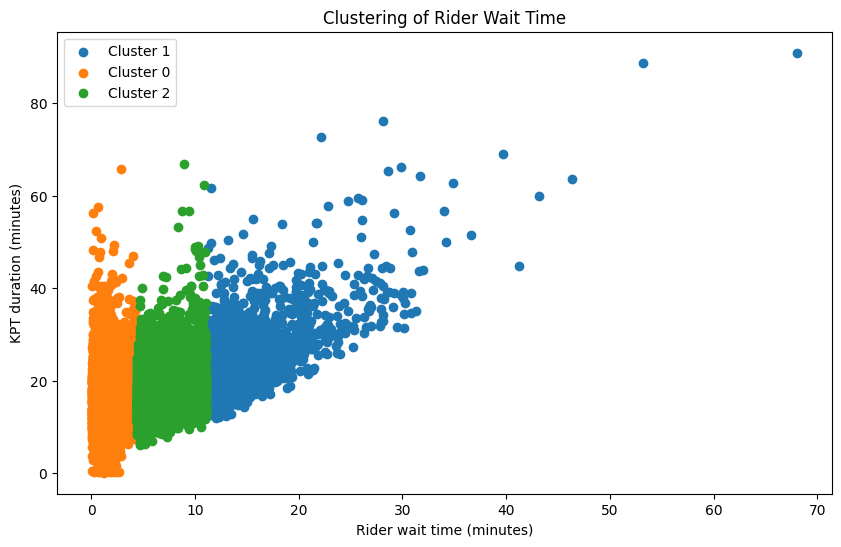

Số lượng dòng trong từng cụm:
Cluster
0    11805
2     5408
1     1841
Name: count, dtype: int64

Trung bình và trung vị của Rider wait time và KPT duration trong từng cụm:
        Rider wait time (minutes)        KPT duration (minutes)       
                             mean median                   mean median
Cluster                                                               
0                        1.466158    1.2              15.721851   15.1
1                       15.101738   13.8              25.088398   23.0
2                        7.295026    7.1              18.055843   17.2

Cảnh báo: Có các dòng dữ liệu với tỷ lệ Rider wait time / KPT duration lớn hơn 40%:
       Rider wait time (minutes)  KPT duration (minutes)     Ratio
0                           11.6                   18.35  0.632153
2                           12.2                   14.05  0.868327
8                            8.3                   15.20  0.546053
10                           5.5                

In [104]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Lấy dữ liệu cần thiết từ correctly_marked
rider_wait_time_data = correctly_marked[['Rider wait time (minutes)', 'KPT duration (minutes)']].dropna()

# Phân cụm với KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
rider_wait_time_data['Cluster'] = kmeans.fit_predict(rider_wait_time_data[['Rider wait time (minutes)']])

# Vẽ biểu đồ phân cụm
plt.figure(figsize=(10, 6))
for cluster in rider_wait_time_data['Cluster'].unique():
    cluster_data = rider_wait_time_data[rider_wait_time_data['Cluster'] == cluster]
    plt.scatter(cluster_data['Rider wait time (minutes)'], cluster_data['KPT duration (minutes)'], label=f'Cluster {cluster}')
plt.xlabel('Rider wait time (minutes)')
plt.ylabel('KPT duration (minutes)')
plt.title('Clustering of Rider Wait Time')
plt.legend()
plt.show()

# Đếm số lượng dòng trong từng cụm
cluster_counts = rider_wait_time_data['Cluster'].value_counts()
print("Số lượng dòng trong từng cụm:")
print(cluster_counts)

# Tính trung bình và trung vị
cluster_stats = rider_wait_time_data.groupby('Cluster').agg({
    'Rider wait time (minutes)': ['mean', 'median'],
    'KPT duration (minutes)': ['mean', 'median']
})
print("\nTrung bình và trung vị của Rider wait time và KPT duration trong từng cụm:")
print(cluster_stats)

# Tính tỷ lệ và kiểm tra cảnh báo
rider_wait_time_data['Ratio'] = rider_wait_time_data['Rider wait time (minutes)'] / rider_wait_time_data['KPT duration (minutes)']
warnings = rider_wait_time_data[rider_wait_time_data['Ratio'] > 0.4]
if not warnings.empty:
    print("\nCảnh báo: Có các dòng dữ liệu với tỷ lệ Rider wait time / KPT duration lớn hơn 40%:")
    print(warnings[['Rider wait time (minutes)', 'KPT duration (minutes)', 'Ratio']])

In [105]:
4# Đếm số lượng dòng cảnh báo trong từng cụm
warning_counts = warnings['Cluster'].value_counts()
print("Số lượng dòng cảnh báo trong từng cụm:")
print(warning_counts)

# Tính khoảng thời gian của từng cụm
cluster_ranges = rider_wait_time_data.groupby('Cluster')['Rider wait time (minutes)'].agg(['min', 'max'])
print("\nKhoảng thời gian (phút) của từng cụm:")
print(cluster_ranges)

Số lượng dòng cảnh báo trong từng cụm:
Cluster
2    2897
1    1748
0      81
Name: count, dtype: int64

Khoảng thời gian (phút) của từng cụm:
          min   max
Cluster            
0         0.1   4.3
1        11.2  68.0
2         4.4  11.1


In [106]:
# Tính các percentiles cho Rider wait time
percentiles = rider_wait_time_data['Rider wait time (minutes)'].quantile([0.3, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99])
# Đọc dữ liệu từ file correctly_marked_orders.csv
correctly_marked_data = pd.read_csv('correctly_marked_orders.csv')

# Tính các percentiles cho Rider wait time
percentiles = correctly_marked_data['Rider wait time (minutes)'].quantile([0.3, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99])

print("Các percentiles của Rider wait time (minutes) từ correctly_marked_orders:")
print(percentiles)

# Xác định ngưỡng chấp nhận được (ví dụ: dưới 90th percentile)
acceptable_threshold = percentiles[0.8]
print(f"\nNgưỡng chấp nhận được của Rider wait time (dựa trên correctly_marked_orders): {acceptable_threshold} phút")
print("Các percentiles của Rider wait time (minutes):")
print(percentiles)

# Xác định ngưỡng chấp nhận được (ví dụ: dưới 90th percentile)
acceptable_threshold = percentiles[0.8]
print(f"\nNgưỡng chấp nhận được của Rider wait time: {acceptable_threshold} phút")

Các percentiles của Rider wait time (minutes) từ correctly_marked_orders:
0.30     1.1
0.50     2.5
0.75     6.9
0.80     8.0
0.90    11.0
0.95    13.7
0.99    20.1
Name: Rider wait time (minutes), dtype: float64

Ngưỡng chấp nhận được của Rider wait time (dựa trên correctly_marked_orders): 8.0 phút
Các percentiles của Rider wait time (minutes):
0.30     1.1
0.50     2.5
0.75     6.9
0.80     8.0
0.90    11.0
0.95    13.7
0.99    20.1
Name: Rider wait time (minutes), dtype: float64

Ngưỡng chấp nhận được của Rider wait time: 8.0 phút


In [107]:
# Lọc các dòng có Rider wait time (minutes) lớn hơn ngưỡng
def new_func():
    above_threshold = rider_wait_time_data[rider_wait_time_data['Rider wait time (minutes)'] > acceptable_threshold]
    return above_threshold

above_threshold = new_func()
above_threshold = above_threshold[above_threshold.index.isin(correctly_marked_data.index)]

# Đếm số dòng
count_above_threshold = len(above_threshold)
print(f"Số dòng có Rider wait time (minutes) lớn hơn ngưỡng {acceptable_threshold}: {count_above_threshold}")

Số dòng có Rider wait time (minutes) lớn hơn ngưỡng 8.0: 3373


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Đọc dữ liệu
data = pd.read_csv('order_history_kaggle_data.csv')

# 2. Xử lý dữ liệu
# Tách số lượng món ăn
data['Items count'] = data['Items in order'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

# Vector hóa tên món ăn
vectorizer = CountVectorizer(tokenizer=lambda x: x.split(', '))
X_items = vectorizer.fit_transform(data['Items in order'].fillna(''))

# Kết hợp số lượng món ăn vào đặc trưng
X = np.hstack([X_items.toarray(), data[['Items count']].values])
y = data['KPT duration (minutes)']

# 3. Loại bỏ các hàng có giá trị NaN trong y
valid_indices = ~y.isna()
X = X[valid_indices]
y = y[valid_indices]

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Huấn luyện mô hình
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Đánh giá mô hình
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

# 6. Hàm dự đoán thời gian KPT cho đơn hàng mới
def predict_kpt(order_items):
    order_vector = vectorizer.transform([order_items])
    order_features = np.hstack([order_vector.toarray(), [[len(order_items.split(', '))]]])
    return model.predict(order_features)[0]

# Ví dụ: Dự đoán thời gian KPT cho một đơn hàng mới
new_order = "1 x Grilled Chicken Jamaican Tender, 1 x Peri Peri Fries"
predicted_time = predict_kpt(new_order)
print(f"Predicted KPT duration: {predicted_time:.2f} minutes")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Mean Absolute Error (MAE): 3.8884589266655087
Root Mean Squared Error (RMSE): 5.534450763528558
R-squared (R²): 0.16723708808929594
Predicted KPT duration: 15.46 minutes


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Đọc dữ liệu
data = pd.read_csv('order_history_kaggle_data.csv')

# 2. Xử lý dữ liệu
# Chuyển đổi thời điểm đặt món thành datetime
data['Order Placed At'] = pd.to_datetime(data['Order Placed At'], format='%I:%M %p, %B %d %Y')

# Trích xuất các đặc trưng thời gian
data['Hour'] = data['Order Placed At'].dt.hour
data['Weekday'] = data['Order Placed At'].dt.weekday
data['Month'] = data['Order Placed At'].dt.month

# Tách số lượng món ăn
data['Items count'] = data['Items in order'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

# Vector hóa tên món ăn
vectorizer = CountVectorizer(tokenizer=lambda x: x.split(', '))
X_items = vectorizer.fit_transform(data['Items in order'].fillna(''))

# Kết hợp số lượng món ăn và đặc trưng thời gian vào ma trận đặc trưng
X = np.hstack([
    X_items.toarray(), 
    data[['Items count', 'Hour', 'Weekday', 'Month']].values
])
y = data['KPT duration (minutes)']

# 3. Loại bỏ các hàng có giá trị NaN trong y
valid_indices = ~y.isna()
X = X[valid_indices]
y = y[valid_indices]

# 4. Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Huấn luyện mô hình
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 6. Đánh giá mô hình
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r2}")

# 7. Hàm dự đoán thời gian KPT cho đơn hàng mới
def predict_kpt(order_items, order_time):
    order_vector = vectorizer.transform([order_items])
    order_features = np.hstack([
        order_vector.toarray(), 
        [[len(order_items.split(', ')), order_time.hour, order_time.weekday(), order_time.month]]
    ])
    return model.predict(order_features)[0]

# Ví dụ: Dự đoán thời gian KPT cho một đơn hàng mới
new_order = "1 x Grilled Chicken Jamaican Tender, 1 x Peri Peri Fries"
order_time = pd.to_datetime("11:38 PM, September 10 2024", format='%I:%M %p, %B %d %Y')
predicted_time = predict_kpt(new_order, order_time)
print(f"Predicted KPT duration: {predicted_time:.2f} minutes")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Mean Absolute Error (MAE): 4.060592003048957
Root Mean Squared Error (RMSE): 5.771307246074226
R-squared (R²): 0.09443274631258858
Predicted KPT duration: 16.23 minutes


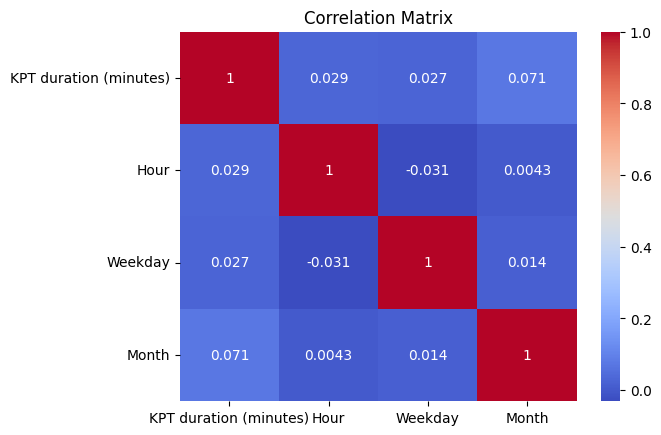

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tính tương quan
correlation_matrix = data[['KPT duration (minutes)', 'Hour', 'Weekday', 'Month']].corr()

# Vẽ heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

                           Category       mean  median  count
0                          Beverage   4.095000    1.24     16
1                   Beverage, Fried  12.606667   13.62      6
2                 Beverage, Grilled  19.510870   16.73     23
3          Beverage, Grilled, Other  29.388305   24.90     59
4   Beverage, Grilled, Other, Fried  20.886316   19.20     19
5                   Beverage, Other  18.324951   16.45    412
6            Beverage, Other, Fried  17.120800   16.52     50
7                             Fried  16.202479   15.48    831
8                           Grilled  18.238805   17.55   4719
9                 Grilled, Beverage  15.438462   15.27     26
10         Grilled, Beverage, Other  27.592121   31.00     33
11  Grilled, Beverage, Other, Fried  22.757209   22.12     43
12                   Grilled, Fried  20.212646   19.05   1198
13                   Grilled, Other  21.151408   19.75   3822
14            Grilled, Other, Fried  23.242275   22.23    998
15      

/var/folders/93/jzhc9xv925g12nywcpx4b7b80000gn/T/ipykernel_63122/2491468245.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_stats, x='Category', y='mean', palette='viridis')


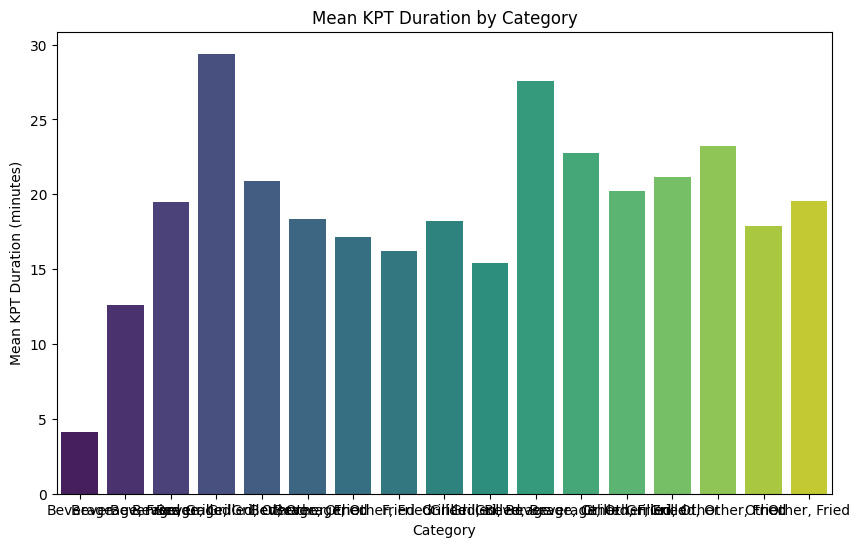

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Đọc dữ liệu
data = pd.read_csv('order_history_kaggle_data.csv')

# Loại bỏ các hàng có giá trị NaN trong 'Items in order' và 'KPT duration (minutes)'
data = data.dropna(subset=['Items in order', 'KPT duration (minutes)'])

# Tạo cột 'Category' dựa trên từ khóa trong tên món ăn
def categorize_item(item):
    if 'Grilled' in item:
        return 'Grilled'
    elif 'Fried' in item:
        return 'Fried'
    elif 'Beverage' in item or 'Soda' in item or 'Juice' in item:
        return 'Beverage'
    elif 'Dessert' in item or 'Cake' in item:
        return 'Dessert'
    else:
        return 'Other'

# Áp dụng phân loại cho từng món ăn
data['Category'] = data['Items in order'].apply(lambda x: ', '.join(set([categorize_item(item) for item in x.split(', ')])))

# Tách từng loại món ăn thành các hàng riêng biệt
data_exploded = data.assign(Item=data['Items in order'].str.split(', ')).explode('Item')

# Gom nhóm theo loại món ăn và tính trung bình KPT
category_stats = data_exploded.groupby('Category')['KPT duration (minutes)'].agg(['mean', 'median', 'count']).reset_index()

# Hiển thị kết quả
print(category_stats)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(data=category_stats, x='Category', y='mean', palette='viridis')
plt.title('Mean KPT Duration by Category')
plt.xlabel('Category')
plt.ylabel('Mean KPT Duration (minutes)')
plt.show()

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Đọc dữ liệu
data = pd.read_csv('order_history_kaggle_data.csv')

# Loại bỏ các hàng có giá trị NaN trong 'Items in order' và 'KPT duration (minutes)'
data = data.dropna(subset=['Items in order', 'KPT duration (minutes)'])

# Tạo cột 'Category' dựa trên từ khóa trong tên món ăn
def categorize_item(item):
    if 'Grilled' in item:
        return 'Grilled'
    elif 'Fried' in item:
        return 'Fried'
    elif 'Beverage' in item or 'Soda' in item or 'Juice' in item:
        return 'Beverage'
    elif 'Dessert' in item or 'Cake' in item:
        return 'Dessert'
    else:
        return 'Other'

# Áp dụng phân loại cho từng món ăn
data['Category'] = data['Items in order'].apply(lambda x: ', '.join(set([categorize_item(item) for item in x.split(', ')])))

# Tách số lượng món ăn
data['Items count'] = data['Items in order'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)

# One-hot encoding cho cột 'Category'
data = pd.get_dummies(data, columns=['Category'], drop_first=True)

# Chọn các đặc trưng và biến mục tiêu
X = data[['Items count'] + [col for col in data.columns if col.startswith('Category_')]]
y = data['KPT duration (minutes)']

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Huấn luyện mô hình Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Dự báo trên tập kiểm tra
y_pred = model.predict(X_test)

# Đánh giá mô hình
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# Ví dụ: Dự đoán thời gian KPT cho một đơn hàng mới
# Ensure the new order matches the feature names used during training
new_order = {
    'Items count': 2,
    'Category_Beverage, Fried': 0,
    'Category_Beverage, Grilled': 0,
    'Category_Beverage, Grilled, Other': 0,
    'Category_Beverage, Grilled, Other, Fried': 0,
    'Category_Beverage, Other': 0,
    'Category_Beverage, Other, Fried': 0,
    'Category_Fried': 0,
    'Category_Grilled': 1,
    'Category_Grilled, Beverage': 0,
    'Category_Grilled, Beverage, Other': 0,
    'Category_Grilled, Beverage, Other, Fried': 0,
    'Category_Grilled, Fried': 0,
    'Category_Grilled, Other': 0,
    'Category_Grilled, Other, Fried': 0,
    'Category_Other': 0,
    'Category_Other, Fried': 0
}
new_order_df = pd.DataFrame([new_order], columns=X.columns)  # Ensure column order matches training data
predicted_kpt = model.predict(new_order_df)[0]
print(f"Predicted KPT duration for the new order: {predicted_kpt:.2f} minutes")

Mean Absolute Error (MAE): 3.99
Root Mean Squared Error (RMSE): 5.54
R-squared (R²): 0.16
Predicted KPT duration for the new order: 19.10 minutes
